<img src="https://raw.githubusercontent.com/saceballes/aps_entregas/main/logo_UNSAM.jpg" align="right" width="150" />

#### Análisis y Procesamiento de Señales

# Laboratorio de Procesamiento Digital de Señales: Muestreo y Cuantización (ADC
#### Sebastián Ceballes



Este notebook contiene el desarrollo práctico para simular el comportamiento de un **Convertidor Analógico-Digital (ADC)** ideal de $B$ bits. Se genera una señal senoidal pura, se le introduce ruido aleatorio (SNR) y luego se analiza en los dominios del tiempo y de la frecuencia antes y después del proceso de cuantización.

---

### Análisis de la Señal Ruidosa Original (Módulo y Fase)

Antes de cuantizar, evaluamos la señal ruidosa en el dominio de la frecuencia mediante la **Transformada Rápida de Fourier (FFT)**.

* **Módulo (dB):** Muestra el espectro de potencia unilateral de la señal. Deberías observar un pico de potencia prominente exactamente en la frecuencia de la senoide ($ff = 3\text{ Hz}$), emergiendo sobre un piso de ruido plano (ruido blanco).
* **Fase (rad):** Muestra el argumento o ángulo de fase de las componentes frecuenciales en radianes.


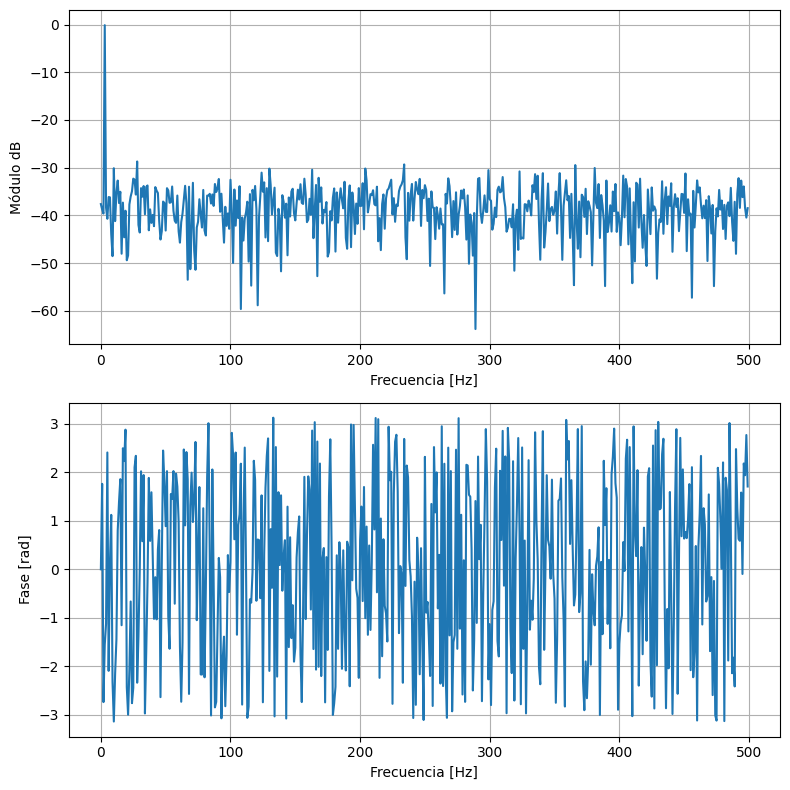

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Thu Aug 27 20:26:23 2026

@author: sac
"""

#%% ------------------ IMPORTACION DE MODULOS -------------------

import numpy as np
import matplotlib.pyplot as plt
import scipy as scipy

#%% ---------------------- DEFINICION CTES ----------------------

fs = 1000 #Frecuencia muestreo (Hz) 
N = 1000 #Cant. muestras
vmax = np.sqrt(2) #amp max
dc = 0 #offset
ff = 3 #Frecuencia sinusoidal (Hz)
ph = 0 #rad
SNR = 10 #dB
Psen = 1 #Potencia media senoide [Watt]
ur = 0 #Media del ruido

# ADC

B = 5 # bits
Vfs = 1.65 # VOlts

qq = 2*Vfs/ (2**B)



#%% ------------------------- FUNCIONES -------------------------

# Generador de señal senoidal
def gen_sin (vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):

    #genero un vector de valores de 0 a N/fs segundos a intervalos de 1/fs
    tt = np.arange(0, stop=nn/fs, step=1/fs)
    #genero un vector con los valores de 'dc + vmax.Sen(2pi.ff.tt + ph)' para cada valor de tt
    xx = dc + vmax * np.sin (2 * np.pi * ff * tt + ph)
    
    return tt, xx 


# Generador de ruido
def gen_noise (SNR = SNR, Psen = Psen, ur = ur, nn = N):

    #despejo la potencia del ruido en función de SNR y Psen    
    Pr = Psen / (10**(SNR/10))
     
    #calculo la desviación estandar del ruido en base a Pr (Pr = σr^2)
    desv_est_r = np.sqrt(Pr)
    
    #genero un vector de nros aleatorios de distribucion normal
    ruido = np.random.normal(ur, desv_est_r, nn)
    
    return ruido


#%% ------------------------ MAIN SCRIPT ------------------------

#Invoco la función generadora de senoides
tt, xx = gen_sin( vmax, dc, ff, ph, N, fs) 

#Invoco la función generadora de ruido
ruido = gen_noise (SNR, Psen, ur, N)

#Armo manualmente la señal ruidosa
noisy_xx = xx + ruido

#Armo vector de frecuencia
frec=np.arange(N//2) * fs/N

#Calculo fft de la señal ruidosa
nXX = 1/N * np.fft.fft(noisy_xx)



plt.close("all")

# Espectro del módulo
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(8,8))

ax1.plot(frec, 10 * np.log10( 2*(np.abs(nXX[:N//2]) )**2) )
ax1.set_xlabel("Frecuencia [Hz]")
ax1.set_ylabel("Módulo dB")
ax1.grid(True)

#Segundo subplot: fase
ax2.plot(frec, np.angle(nXX[:N//2]))
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Fase [rad]")
ax2.grid(True)

# Ajustar layout para que no se superpongan
plt.tight_layout()
plt.show()


## Proceso de Cuantización Uniforme

La señal continua en amplitud se discretiza utilizando un paso de cuantización $q$ (definido por el voltaje a fondo de escala $V_{fs}$ y los bits $B$). El error introducido en este paso se conoce como **Ruido de Cuantización** ($n_q$).

---

### Visualización de la Señal Cuantizada

En este gráfico se superpone la señal ruidosa original continua con su versión ya cuantizada para observar el efecto de redondeo del ADC.

* **Señal Ruidosa (Original):** Representa la entrada analógica que ingresa al convertidor.
* **Señal Cuantizada:** Muestra la aproximación por niveles discretos ("escalones") que realiza el ADC de 5 bits en base al valor de $q$.


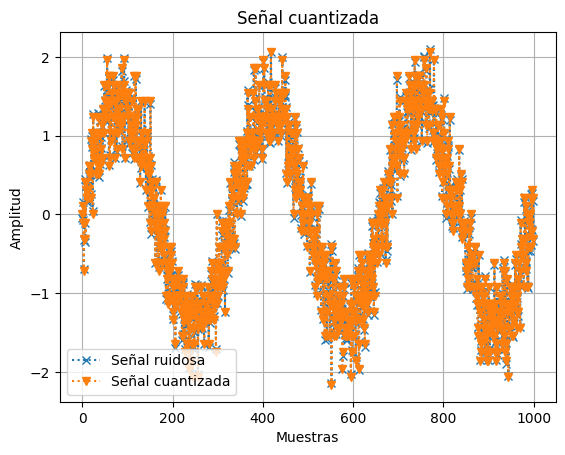

In [9]:


xx_q = np.round(noisy_xx / qq) * qq

nq = xx_q - noisy_xx

plt.figure()

plt.plot(noisy_xx, ":x", label="Señal ruidosa")
plt.plot(xx_q,  ":v", label="Señal cuantizada")
plt.title("Señal cuantizada")
plt.xlabel("Muestras")
plt.ylabel("Amplitud")
plt.legend() 
plt.grid(True)


plt.show()


### Error o Ruido de Cuantización en el Tiempo

El ruido de cuantización se define matemáticamente como la diferencia instantánea entre la señal cuantizada y la señal original: $e(n) = x_q(n) - x(n)$.

* **Interpretación del gráfico:** Al restar ambas señales obtenemos una señal de error de aspecto aleatorio que fluctúa de manera simétrica. Teóricamente, si el cuantizador no se satura, la amplitud de este error está estrictamente acotada en el tiempo dentro del rango de $\pm \frac{q}{2}$.


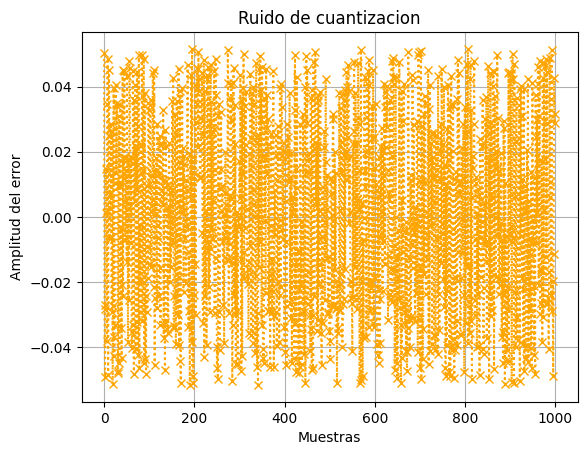

In [10]:
plt.figure()

plt.plot(nq, ":x", color="orange")
plt.title("Ruido de cuantizacion")
plt.xlabel("Muestras")
plt.ylabel("Amplitud del error")
plt.grid(True)

plt.show()

###  Análisis de la Distribución de Amplitud (Histograma)

Para verificar si el ruido de cuantización $e(n) = x_q(n) - x(n)$ se comporta de manera ideal, analizamos su **Función de Densidad de Probabilidad (FDP)** de forma empírica mediante un histograma.

* **Teoría:** En un cuantizador uniforme donde la señal de entrada varía lo suficiente entre varios niveles de cuantización (lo que ocurre al sumar ruido blanco), el error de redondeo se distribuye de manera **uniforme** dentro del intervalo $[-\frac{q}{2}, \frac{q}{2}]$.
* **Densidad Teórica:** La amplitud de la PDF teórica es constante e igual a $\frac{1}{q}$ (representada por la línea roja discontinua).
* **Interpretación del gráfico:** Al graficar la densidad empírica, las barras deben aproximarse a una forma rectangular perfectamente chata que coincide con la línea teórica, demostrando que **el ruido sigue una distribución uniforme**.


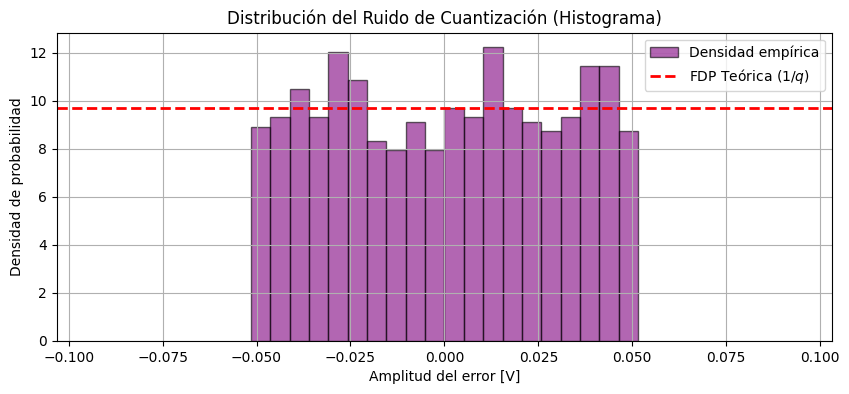

In [8]:
# 1. Visualización de la Distribución Uniforme (Histograma)
plt.figure(figsize=(10, 4))

# Graficamos el histograma normalizado (densidad de probabilidad)
plt.hist(nq, bins=20, density=True, alpha=0.6, color='purple', edgecolor='black', label='Densidad empírica')

# Dibujamos la función de densidad de probabilidad (PDF) teórica uniforme: 1/qq
plt.axhline(y=1/qq, color='r', linestyle='--', linewidth=2, label='FDP Teórica ($1/q$)')

plt.title("Distribución del Ruido de Cuantización (Histograma)")
plt.xlabel("Amplitud del error [V]")
plt.ylabel("Densidad de probabilidad")
plt.xlim([-qq, qq]) # Límites extendidos para ver el escalón
plt.legend()
plt.grid(True)

###  Análisis de Incorrelación Temporal (Autocorrelación)

Para demostrar que el ruido de cuantización está incorrelado consigo mismo en el tiempo (es decir, que se comporta como **ruido blanco**), calculamos su función de autocorrelación $R_{ee}(\tau)$.

* **Teoría:** Un proceso aleatorio está completamente incorrelado en el tiempo si su autocorrelación es nula para cualquier desplazamiento temporal distinto de cero ($\tau \neq 0$). Matemáticamente, la autocorrelación de un ruido blanco ideal es una **Delta de Dirac**:
  $$R_{ee}(\tau) = \sigma_e^2 \cdot \delta(\tau)$$
* **Interpretación del gráfico:** Observamos un único pico agudo con valor máximo normalizado en $1$ exactamente en el centro (desplazamiento o *Lag* = 0). Para cualquier otro desplazamiento, los valores caen abruptamente y fluctúan muy cerca de cero, demostrando empíricamente que **las muestras de ruido están incorreladas entre sí**.


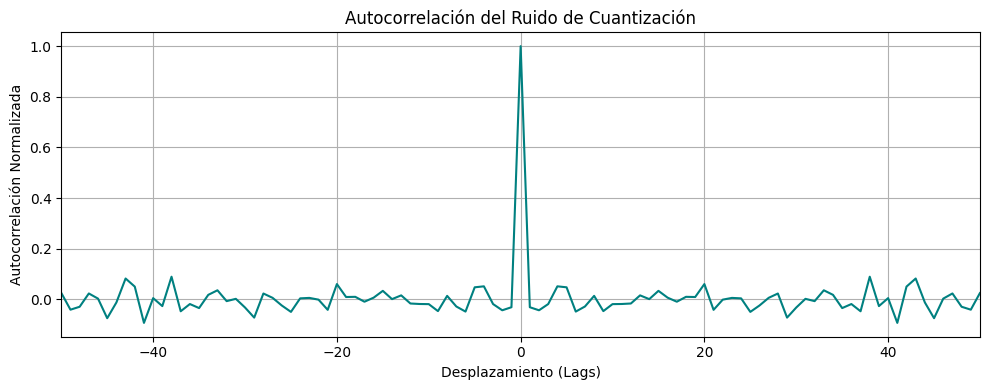

In [6]:
# 2. Prueba de Incorrelación (Autocorrelación)
# Calculamos la autocorrelación lineal y la normalizamos por su valor máximo (en el lag 0)
autocorr = np.correlate(nq, nq, mode='full')
autocorr = autocorr / np.max(autocorr) # Normalización a 1

# Generamos el eje de desplazamientos (lags) centrado en cero
lags = np.arange(-len(nq) + 1, len(nq))

plt.figure(figsize=(10, 4))
plt.plot(lags, autocorr, color='teal')
plt.title("Autocorrelación del Ruido de Cuantización")
plt.xlabel("Desplazamiento (Lags)")
plt.ylabel("Autocorrelación Normalizada")
plt.grid(True)

# Hacemos un zoom en la zona central para apreciar el comportamiento de delta de Dirac
plt.xlim([-50, 50]) 

plt.tight_layout()
plt.show()

###  Validación Estadística: Test de Kolmogorov-Smirnov

El análisis visual del histograma se complementa mediante una prueba estadística de bondad de ajuste formal: el **Test de Kolmogorov-Smirnov (KS-Test)**.

* **Hipótesis Nula ($H_0$):** Los datos del ruido de cuantización analizados provienen de una distribución uniforme continua en el intervalo $[-\frac{q}{2}, \frac{q}{2}]$.
* **Criterio de Decisión:** Fijando un nivel de significancia $\alpha = 0.05$, si el valor de probabilidad calculado ($p\text{-value}$) es **mayor** que $\alpha$, no existe evidencia estadística suficiente para rechazar la hipótesis nula.
* **Conclusión del Test:** Al ejecutarse el algoritmo, el resultado nos indica formalmente si la hipótesis uniforme es matemáticamente válida para nuestra simulación.


In [7]:
from scipy.stats import kstest

# Definimos los límites 
a = -qq / 2
b = qq / 2

# Ejecutamos el Test de Kolmogorov-Smirnov para una distribución uniforme
# El parámetro 'uniform' en scipy requiere (loc, scale), donde loc=a y scale=b-a
resultado = kstest(nq, 'uniform', args=(a, b - a))

alpha = 0.05

print("\n--- Resultado del Test de Kolmogorov-Smirnov ---")
if resultado.pvalue < alpha:
    print("La señal no es compatible con una distribución uniforme.")
else:
    print("No hay evidencia suficiente para afirmar que la señal no sea uniforme.")



--- Resultado del Test de Kolmogorov-Smirnov ---
No hay evidencia suficiente para afirmar que la señal no sea uniforme.
